In [1]:

url = "https://raw.githubusercontent.com/arkadhar01/ML-Assignment/main/problem_set_2/bank-full.csv"





In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully ")


All libraries imported successfully 


In [3]:
#STEP 1 — LOAD AND UNDERSTAND THE DATASET

print("=" * 65)
print("STEP 1: LOAD AND UNDERSTAND THE DATASET")
print("=" * 65)

# NOTE: The bank-full.csv uses semicolon (;) as separator
df = pd.read_csv(url, sep=';')

print(f"\n Shape of Dataset : {df.shape}")
print(f" Rows             : {df.shape[0]}")
print(f" Columns          : {df.shape[1]}")

print("\n── First 5 Rows ──────────────────────────────────────────")
print(df.head())

print("\n── Column Names & Data Types ─────────────────────────────")
print(df.dtypes)

print("\n── Basic Statistical Summary ─────────────────────────────")
print(df.describe())

print("\n── Missing Values per Column ─────────────────────────────")
print(df.isnull().sum())

print("\n── Target Variable (y) Distribution ─────────────────────")
print(df['y'].value_counts())
print("\nPercentage:")
print((df['y'].value_counts(normalize=True) * 100).round(2))


STEP 1: LOAD AND UNDERSTAND THE DATASET

 Shape of Dataset : (45211, 17)
 Rows             : 45211
 Columns          : 17

── First 5 Rows ──────────────────────────────────────────
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  


STEP 2: EXPLORATORY DATA ANALYSIS (EDA)


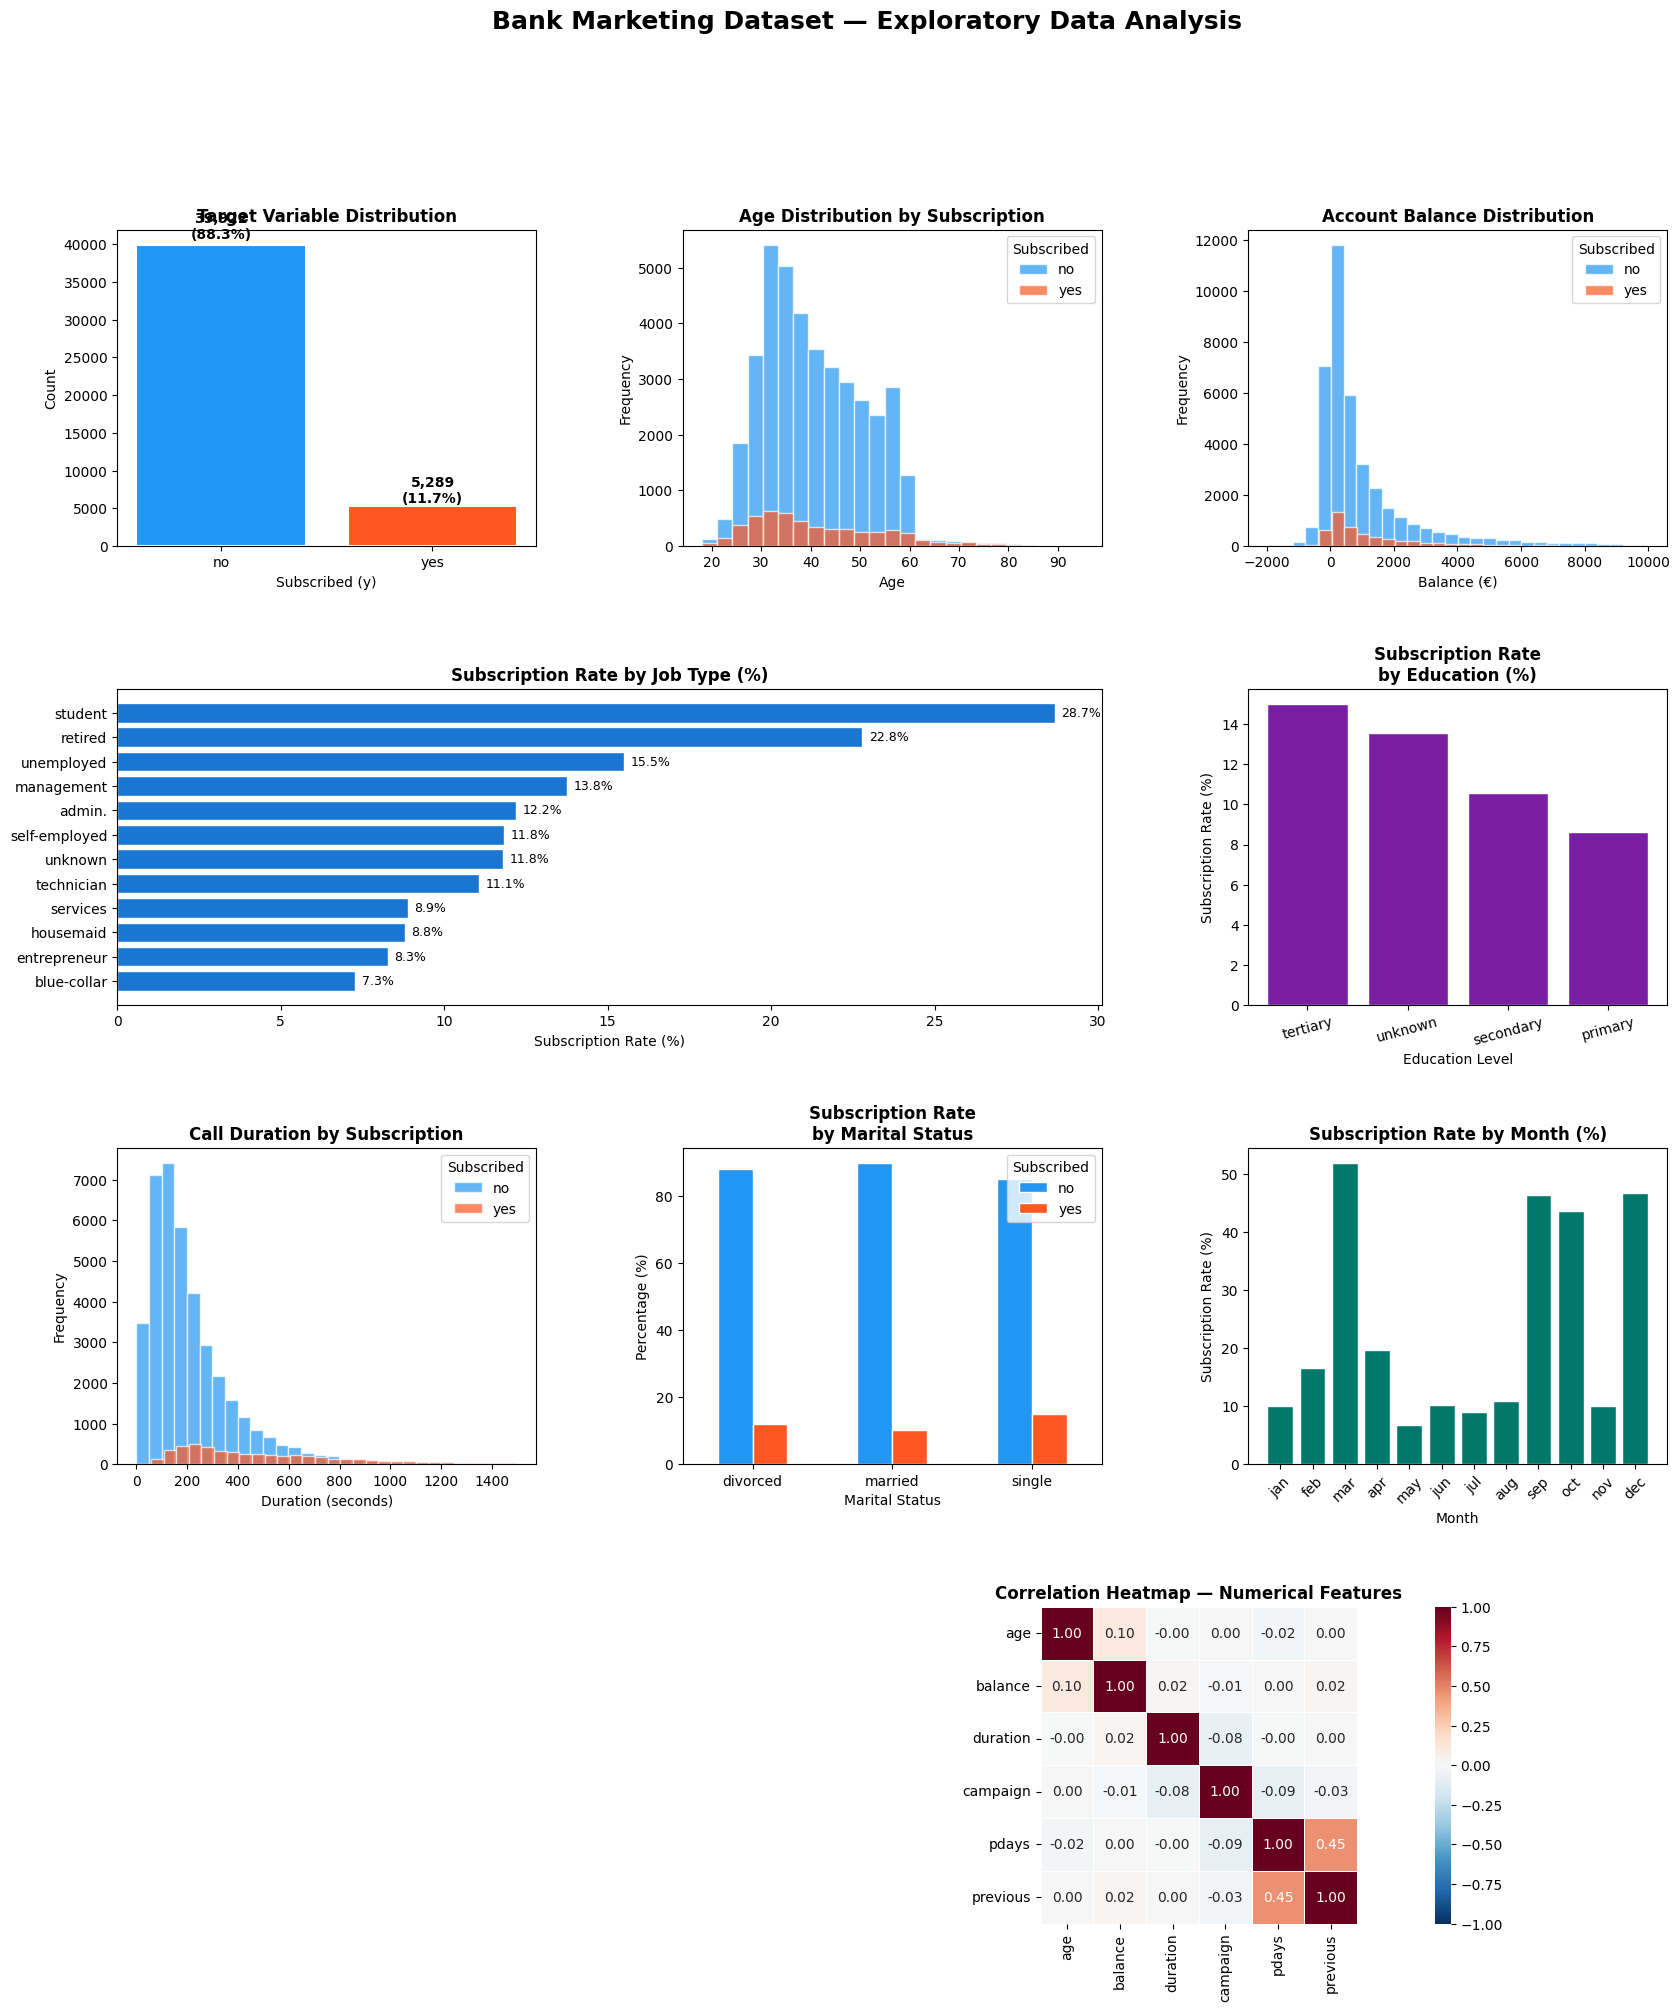


[Figure 1 saved → fig1_eda.png]


In [4]:

# STEP 2 — EXPLORATORY DATA ANALYSIS (EDA)


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import numpy as np

print("\n" + "=" * 65)
print("STEP 2: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 65)

colors_2 = ['#2196F3', '#FF5722']

fig = plt.figure(figsize=(20, 22))
fig.suptitle(
    'Bank Marketing Dataset — Exploratory Data Analysis',
    fontsize=18, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

#  Target Distribution ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = df['y'].value_counts()

bars = ax1.bar(
    counts.index,
    counts.values,
    color=colors_2,
    edgecolor='white',
    linewidth=1.5
)

ax1.set_title('Target Variable Distribution', fontweight='bold')
ax1.set_xlabel('Subscribed (y)')
ax1.set_ylabel('Count')

for bar, val in zip(bars, counts.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{val:,}\n({val / len(df) * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

#  Age Distribution ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

for label, color in zip(['no', 'yes'], colors_2):
    ax2.hist(
        df[df['y'] == label]['age'],
        bins=25,
        alpha=0.7,
        color=color,
        label=label,
        edgecolor='white'
    )

ax2.set_title('Age Distribution by Subscription', fontweight='bold')
ax2.set_xlabel('Age')
ax2.set_ylabel('Frequency')
ax2.legend(title='Subscribed')

# Balance Distribution ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])

for label, color in zip(['no', 'yes'], colors_2):
    data = df[df['y'] == label]['balance']

    ax3.hist(
        data[data.between(-2000, 10000)],
        bins=30,
        alpha=0.7,
        color=color,
        label=label,
        edgecolor='white'
    )

ax3.set_title('Account Balance Distribution', fontweight='bold')
ax3.set_xlabel('Balance (€)')
ax3.set_ylabel('Frequency')
ax3.legend(title='Subscribed')

# Job vs Subscription Rate ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])

job_rate = (
    df.groupby('job')['y']
    .apply(lambda x: (x == 'yes').mean() * 100)
    .sort_values(ascending=True)
)

bars4 = ax4.barh(
    job_rate.index,
    job_rate.values,
    color='#1976D2',
    edgecolor='white'
)

ax4.set_title('Subscription Rate by Job Type (%)', fontweight='bold')
ax4.set_xlabel('Subscription Rate (%)')

for bar, val in zip(bars4, job_rate.values):
    ax4.text(
        val + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center',
        fontsize=9
    )

# Education vs Subscription Rate ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])

edu_rate = (
    df.groupby('education')['y']
    .apply(lambda x: (x == 'yes').mean() * 100)
    .sort_values(ascending=False)
)

ax5.bar(
    edu_rate.index,
    edu_rate.values,
    color='#7B1FA2',
    edgecolor='white'
)

ax5.set_title('Subscription Rate\nby Education (%)', fontweight='bold')
ax5.set_xlabel('Education Level')
ax5.set_ylabel('Subscription Rate (%)')
ax5.tick_params(axis='x', rotation=15)

#  Call Duration vs Subscription ────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])

for label, color in zip(['no', 'yes'], colors_2):
    data = df[df['y'] == label]['duration']

    ax6.hist(
        data[data < 1500],
        bins=30,
        alpha=0.7,
        color=color,
        label=label,
        edgecolor='white'
    )

ax6.set_title('Call Duration by Subscription', fontweight='bold')
ax6.set_xlabel('Duration (seconds)')
ax6.set_ylabel('Frequency')
ax6.legend(title='Subscribed')

# Marital Status vs Subscription ───────────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])

mar_sub = df.groupby(['marital', 'y']).size().unstack()
mar_pct = mar_sub.div(mar_sub.sum(axis=1), axis=0) * 100

mar_pct.plot(
    kind='bar',
    ax=ax7,
    color=colors_2,
    edgecolor='white'
)

ax7.set_title('Subscription Rate\nby Marital Status', fontweight='bold')
ax7.set_xlabel('Marital Status')
ax7.set_ylabel('Percentage (%)')
ax7.legend(title='Subscribed', loc='upper right')
ax7.tick_params(axis='x', rotation=0)

#  Month vs Subscription Rate ──────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])

month_order = [
    'jan','feb','mar','apr','may','jun',
    'jul','aug','sep','oct','nov','dec'
]

month_rate = (
    df.groupby('month')['y']
    .apply(lambda x: (x == 'yes').mean() * 100)
    .reindex(month_order, fill_value=0)
)

ax8.bar(
    month_rate.index,
    month_rate.values,
    color='#00796B',
    edgecolor='white'
)

ax8.set_title('Subscription Rate by Month (%)', fontweight='bold')
ax8.set_xlabel('Month')
ax8.set_ylabel('Subscription Rate (%)')
ax8.tick_params(axis='x', rotation=45)

# Correlation Heatmap ──────────────────────────────────────────────
ax9 = fig.add_subplot(gs[3, :])

num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
corr = df[num_cols].corr()

sns.heatmap(
    corr,
    ax=ax9,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1
)

ax9.set_title('Correlation Heatmap — Numerical Features', fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_eda.png', dpi=150, bbox_inches='tight', facecolor='white')


plt.show()


plt.close()

print("\n[Figure 1 saved → fig1_eda.png]")

In [5]:

# STEP 3 — DATA PREPROCESSING

print("\n" + "=" * 65)
print("STEP 3: DATA PREPROCESSING")
print("=" * 65)

df_model = df.copy()

# Encode Categorical Variables ─────────────────────────────────────────
cat_cols = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'month', 'poutcome'
]
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"  Encoded : {col}")

#  Encode Target Variable ────────────────────────────────────────────────
df_model['y'] = (df_model['y'] == 'yes').astype(int)
print(f"\n  Target encoded — yes=1, no=0")
print(f"  Target distribution after encoding:\n{df_model['y'].value_counts()}")

#  Split Features and Target ─────────────────────────────────────────────
X = df_model.drop('y', axis=1)
y_target = df_model['y']
print(f"\n  Features (X) shape : {X.shape}")
print(f"  Target  (y) shape : {y_target.shape}")

#  Train / Test Split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2, random_state=42, stratify=y_target
)
print(f"\n  Train set : {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"  Test  set : {X_test.shape[0]}  rows ({X_test.shape[0]/len(df)*100:.1f}%)")

#  Feature Scaling ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\n  StandardScaler applied — fit on train, transform on test")



STEP 3: DATA PREPROCESSING
  Encoded : job
  Encoded : marital
  Encoded : education
  Encoded : default
  Encoded : housing
  Encoded : loan
  Encoded : contact
  Encoded : month
  Encoded : poutcome

  Target encoded — yes=1, no=0
  Target distribution after encoding:
y
0    39922
1     5289
Name: count, dtype: int64

  Features (X) shape : (45211, 16)
  Target  (y) shape : (45211,)

  Train set : 36168 rows (80.0%)
  Test  set : 9043  rows (20.0%)

  StandardScaler applied — fit on train, transform on test


In [8]:
#STEP 4 — BUILD THE LOGISTIC REGRESSION MODEL

print("\n" + "=" * 65)
print("STEP 4: BUILD LOGISTIC REGRESSION MODEL")
print("=" * 65)

model = LogisticRegression(
    random_state=42,
    max_iter=10000,
    C=1.0,          # Regularization strength (smaller = stronger)
    solver='lbfgs'  # Efficient for small-medium datasets
)
model.fit(X_train_sc, y_train)

print("\n  Model Parameters:")
print(f"    Solver      : lbfgs")
print(f"    C (inverse regularization) : 1.0")
print(f"    max_iter    : 1000")
print(f"    random_state: 42")
print("\n  Model trained successfully on training data!")


STEP 4: BUILD LOGISTIC REGRESSION MODEL

  Model Parameters:
    Solver      : lbfgs
    C (inverse regularization) : 1.0
    max_iter    : 1000
    random_state: 42

  Model trained successfully on training data!


In [10]:
# STEP 5 — EVALUATE THE MODEL
print("\n" + "=" * 65)
print("STEP 5: MODEL EVALUATION")
print("=" * 65)

y_pred      = model.predict(X_test_sc)
y_pred_prob = model.predict_proba(X_test_sc)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)
cm  = confusion_matrix(y_test, y_pred)

print(f"\n┌─────────────────────────────────────┐")
print(f"  │  Accuracy  : {acc:.4f} ({acc*100:.2f}%) │")
print(f"  │  ROC-AUC   : {roc:.4f}                  │")
print(f"  └─────────────────────────────────────┘")

print("\n── Confusion Matrix ──────────────────────────────────────")
print(f"                 Predicted No   Predicted Yes")
print(f"  Actual No         {cm[0,0]:>6}          {cm[0,1]:>6}")
print(f"  Actual Yes        {cm[1,0]:>6}          {cm[1,1]:>6}")

TP = cm[1, 1]; TN = cm[0, 0]; FP = cm[0, 1]; FN = cm[1, 0]
print(f"\n  True  Positives (TP) : {TP}")
print(f"  True  Negatives (TN) : {TN}")
print(f"  False Positives (FP) : {FP}  ← predicted yes but actually no")
print(f"  False Negatives (FN) : {FN}  ← predicted no  but actually yes")

print("\n── Classification Report ─────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

# ── FIGURE 2: Model Evaluation Plots ─────────────────────────────────────────
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle(
    'Logistic Regression — Model Evaluation Results',
    fontsize=16, fontweight='bold'
)

# 2a Confusion Matrix Heatmap
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes'],
    linewidths=1.5, linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title(f'Confusion Matrix\nAccuracy = {acc:.4f}', fontweight='bold')

# 2b ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#1976D2', lw=2.5,
             label=f'Logistic Regression (AUC = {roc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5,
             linestyle='--', label='Random Classifier (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#1976D2')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

# 2c Feature Coefficients (Importance)
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
feat_colors = ['#FF5722' if c < 0 else '#2196F3' for c in coefs.values]
axes[2].barh(coefs.index, coefs.values, color=feat_colors, edgecolor='white')
axes[2].axvline(0, color='black', lw=1)
axes[2].set_title(
    'Feature Coefficients\nBlue = Increases Subscription   '
    'Red = Decreases Subscription',
    fontweight='bold', fontsize=9
)
axes[2].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('fig2_model_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.close()
print("\n  [Figure 2 saved → fig2_model_evaluation.png]")



STEP 5: MODEL EVALUATION

┌─────────────────────────────────────┐
  │  Accuracy  : 0.8914 (89.14%) │
  │  ROC-AUC   : 0.8726                  │
  └─────────────────────────────────────┘

── Confusion Matrix ──────────────────────────────────────
                 Predicted No   Predicted Yes
  Actual No           7822             163
  Actual Yes           819             239

  True  Positives (TP) : 239
  True  Negatives (TN) : 7822
  False Positives (FP) : 163  ← predicted yes but actually no
  False Negatives (FN) : 819  ← predicted no  but actually yes

── Classification Report ─────────────────────────────────
              precision    recall  f1-score   support

      No (0)       0.91      0.98      0.94      7985
     Yes (1)       0.59      0.23      0.33      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043


  [Figure 2 saved → fig2_model_evaluation.png]


In [29]:
# STEP 6 — FEATURE INTERPRETATION

print("\n" + "=" * 65)
print("STEP 6: FEATURE INTERPRETATION")
print("=" * 65)

coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio' : np.exp(model.coef_[0])
}).sort_values('Coefficient', ascending=False)

print("\n  Feature Coefficients (sorted by importance):")
print(f"\n  {'Feature':<12} {'Coefficient':>12} {'Odds Ratio':>12}")
print("  " + "-" * 40)
for _, row in coef_df.iterrows():
    direction = "▲ Increases" if row['Coefficient'] > 0 else "▼ Decreases"
    print(f"  {row['Feature']:<12} {row['Coefficient']:>12.4f} "
          f"{row['Odds Ratio']:>12.4f}   {direction} subscription odds")

print("\n  Key Insight:")
print("  • duration has the highest positive coefficient →")
print("    Longer phone calls strongly predict subscription.")
print("  • pdays (days since last contact) also matters.")
print("  • campaign (number of contacts) negatively affects subscription.")


STEP 6: FEATURE INTERPRETATION

  Feature Coefficients (sorted by importance):

  Feature       Coefficient   Odds Ratio
  ----------------------------------------
  duration           1.0287       2.7975   ▲ Increases subscription odds
  pdays              0.3849       1.4695   ▲ Increases subscription odds
  poutcome           0.2484       1.2820   ▲ Increases subscription odds
  previous           0.2044       1.2268   ▲ Increases subscription odds
  education          0.1408       1.1512   ▲ Increases subscription odds
  marital            0.1310       1.1400   ▲ Increases subscription odds
  month              0.1138       1.1206   ▲ Increases subscription odds
  age                0.0819       1.0854   ▲ Increases subscription odds
  balance            0.0621       1.0641   ▲ Increases subscription odds
  job                0.0316       1.0321   ▲ Increases subscription odds
  day               -0.0371       0.9636   ▼ Decreases subscription odds
  default           -0.0574     

In [28]:

### TEST MODEL WITH NEW CUSTOMER DATA


# Example new customer
new_customer = pd.DataFrame([{
    'age': 35,
    'job': 'management',
    'marital': 'married',
    'education': 'tertiary',
    'default': 'no',
    'balance': 5000,
    'housing': 'yes',
    'loan': 'no',
    'contact': 'cellular',
    'day': 15,
    'month': 'may',
    'duration': 300,
    'campaign': 2,
    'pdays': -1,
    'previous': 0,
    'poutcome': 'unknown'
}])

# Apply same one-hot encoding
new_customer_encoded = pd.get_dummies(new_customer)

# Match training columns exactly
new_customer_encoded = new_customer_encoded.reindex(columns=X.columns, fill_value=0)

# Scale using the SAME scaler
new_customer_scaled = scaler.transform(new_customer_encoded)

# Predict class
prediction = model.predict(new_customer_scaled)[0]

# Predict probability
prediction_prob = model.predict_proba(new_customer_scaled)[0][1]

# Show result
print("Predicted Class:", prediction)
print("Probability of Subscription:", prediction_prob)

if prediction == 1:
    print("Result: Customer is likely to SUBSCRIBE to term deposit.")
else:
    print("Result: Customer is NOT likely to subscribe to term deposit.")

Predicted Class: 0
Probability of Subscription: 0.05324220803520246
Result: Customer is NOT likely to subscribe to term deposit.
